# Testing OT with distance weights, Bulk
Now that we have a tweakable distance function, we can test what manipulations with this function look like for real data and test the effects on OT values.

## Imports

In [2]:
# Enabling Fast Reload 
%load_ext autoreload
%autoreload 2

# Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, dist_weights, get_cool_name, hic_ot_source_to_targets, bin_contact_map
from hicvisutils import hic_vis_matrix

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

## Rescaling and Visualizing

In [3]:
### Defining lists and parameters ###
base_map = chr1s[0]
base_map_name = map_names[0]
max_dist = base_map.shape[0] - 1

# Parameters
gamma_list = np.array([
    0.25, 0.5, 0.75, 
    1.0, 1.25, 1.5, 
    2.0, 3.0, 4.0
    ])
d_fracs = np.array([
    0, 0.01, 0.025, 
    0.05, 0.10, 0.15, 
    0.20, 0.30, 0.40
    ])
d_list = np.round(d_fracs * max_dist).astype(int)

np.int64(36852)

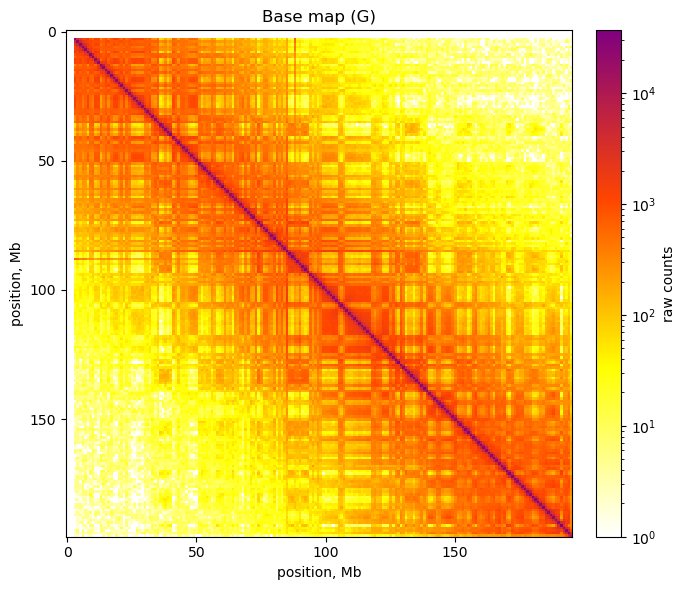

In [ ]:
### Visualizing base map ###
hic_vis_matrix(base_map, title=f"Base map ({base_map_name})", cmap="higlass")

### Gamma

Text(0.5, 0.98, 'Applying gamma to bulk dataset (G)')

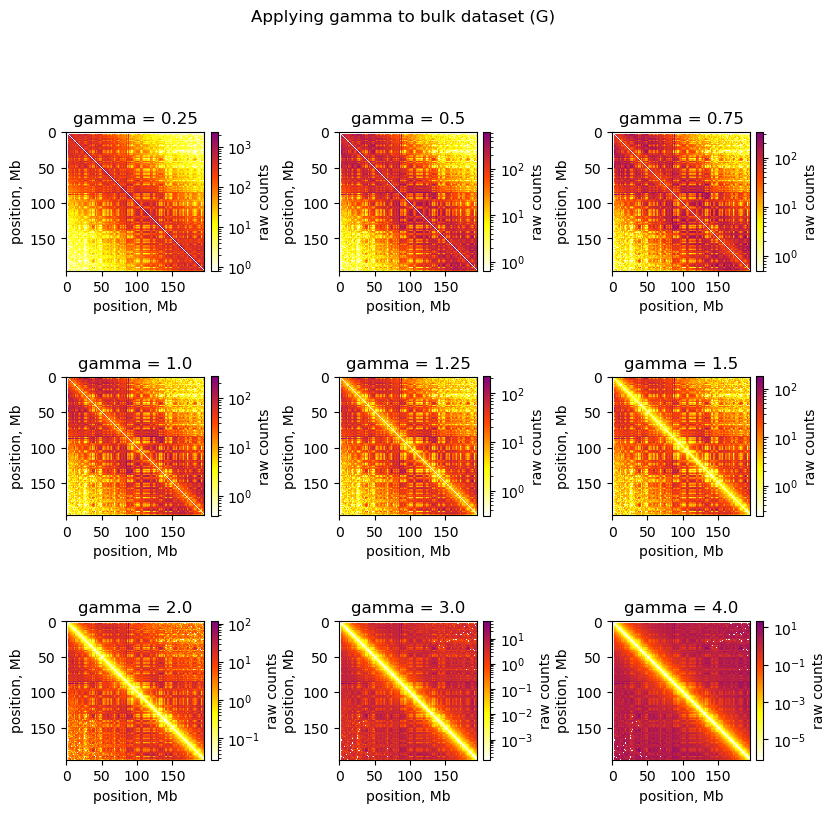

In [4]:
### Generating and visualizing ###
gamma_maps = []
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax, g in zip(axes.flat, gamma_list):
    map = dist_weights(base_map, gamma=g)
    gamma_maps.append(map)
    hic_vis_matrix(map, f"gamma = {g}", cmap="higlass", ax=ax)
fig.subplots_adjust(wspace=0.8)
fig.suptitle(f"Applying gamma to bulk dataset ({base_map_name})")

### d0

Text(0.5, 0.98, 'Applying d0 to bulk dataset (G)')

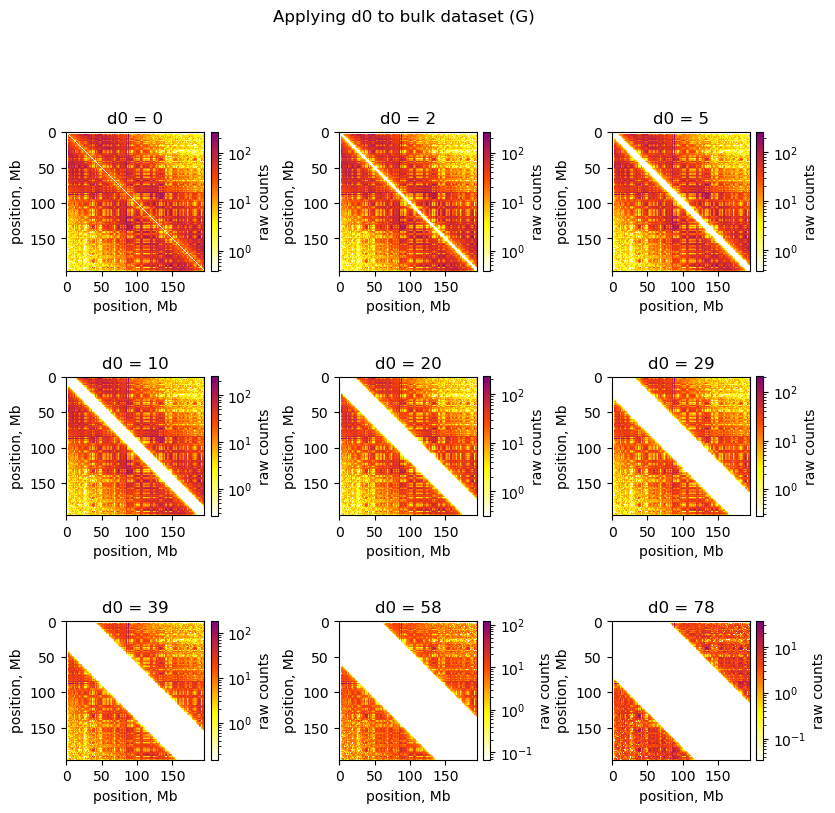

In [5]:
### Generating and visualizing ###
d0_maps = []
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax, d0 in zip(axes.flat, d_list):
    map = dist_weights(base_map, d0=d0)
    gamma_maps.append(map)
    hic_vis_matrix(map, f"d0 = {d0}", cmap="higlass", ax=ax)
fig.subplots_adjust(wspace=0.8)
fig.suptitle(f"Applying d0 to bulk dataset ({base_map_name})")

### d1

Text(0.5, 0.98, 'Applying d1 to bulk dataset (G)')

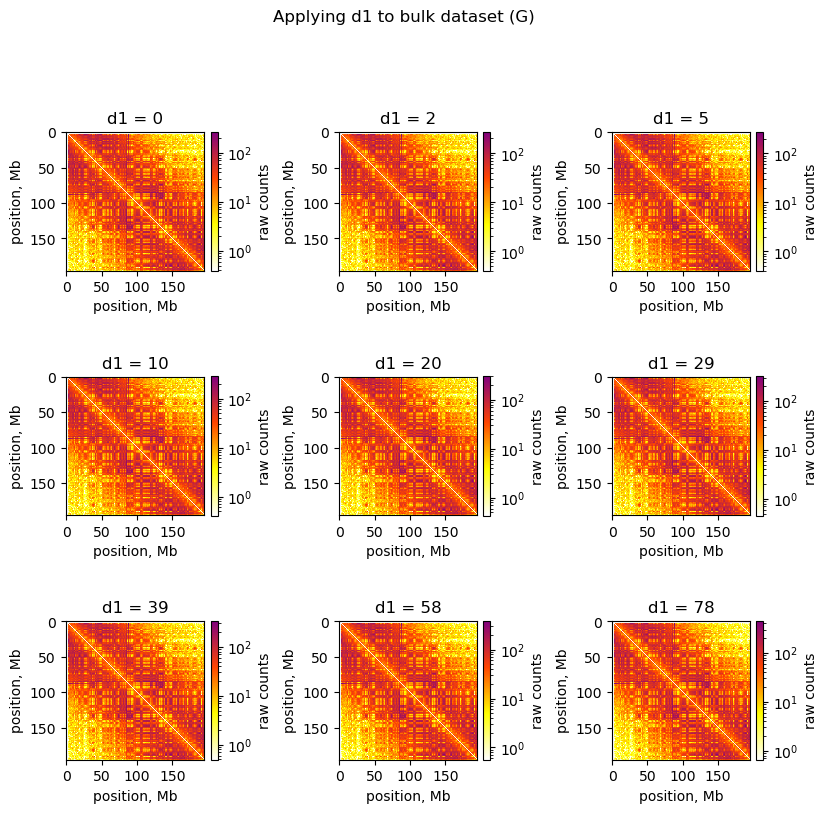

In [6]:
### Generating and visualizing ###
d1_maps = []
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax, d1 in zip(axes.flat, d_list):
    map = dist_weights(base_map, d1=d1)
    gamma_maps.append(map)
    hic_vis_matrix(map, f"d1 = {d1}", cmap="higlass", ax=ax)
fig.subplots_adjust(wspace=0.8)
fig.suptitle(f"Applying d1 to bulk dataset ({base_map_name})")

## Testing Single OT Comparison
Now that we know the function is applicable to bulk maps, we can test the effects of gamma, d0 and d1 on OT comparisons.

In [7]:
### Defining base parameters ###
source_base = chr1s[0]
source_name = map_names[0]
target_base = chr1s[1]
target_name = map_names[1]

res = 8

    # Generating binned maps for original maps
source_base_binned = bin_contact_map(source_base, res)
target_base_binned = bin_contact_map(target_base, res)

    # Generating base OT value
base_ot = hic_ot_source_to_targets(source_base_binned, [target_base_binned], norm="sum")
print(base_ot)

[0.3680452016109758]


### Gamma

In [8]:
### Generating source and target ###
gamma_sources = []
gamma_targets = []

for g in gamma_list:
    # Distance weighing and binning to 8 Mb
    source_dist_map = dist_weights(source_base, gamma=g)
    target_dist_map = dist_weights(target_base, gamma=g)
    source_binned_map = bin_contact_map(source_dist_map, res)
    target_binned_map = bin_contact_map(target_dist_map, res)

    gamma_sources.append(source_binned_map)
    gamma_targets.append([target_binned_map])

In [9]:
### OT ###
gamma_ot_results = []

for source, target in zip(gamma_sources, gamma_targets):
    gamma_ot_results.append(hic_ot_source_to_targets(source, target, norm="sum")[0])

In [10]:
### Organizing data ###
gamma_df = pd.DataFrame({'gamma': gamma_list, "ot_value": gamma_ot_results})
gamma_df

,gamma,ot_value
0,0.25,0.388494
1,0.50,0.424321
2,0.75,0.476489
3,1.00,0.556817
4,1.25,0.668967
5,1.50,0.821900
6,2.00,1.234446
7,3.00,2.251783
8,4.00,2.847606


Text(0.5, 1.0, 'Effect of gamma on Exact OT results (8 Mb, 0%)')

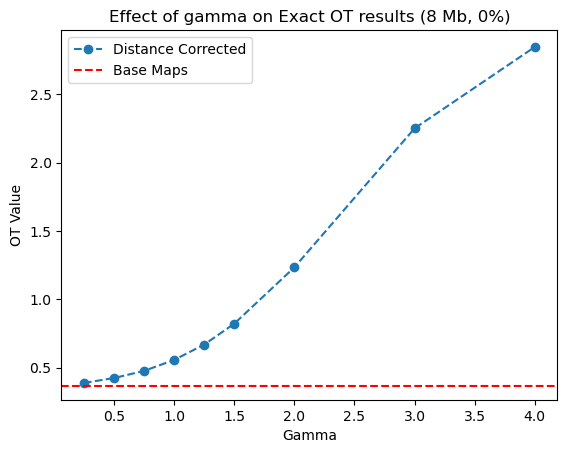

In [11]:
### Plotting ###
gamma_df.plot(x='gamma', y='ot_value', marker="o", linestyle="--", label="Distance Corrected")
plt.xlabel("Gamma")
plt.ylabel("OT Value")
plt.axhline(base_ot, c="red", linestyle="--", label="Base Maps")
plt.legend()
plt.title(f"Effect of gamma on Exact OT results ({res} Mb, 0%)")

### d0 + d1

In [12]:
### Generating source and target ###
d0_sources = []
d1_sources = []
d0_targets = []
d1_targets = []

for d in d_list:
    # Distance weighing and binning to 8 Mb
    source_dist_map_0 = dist_weights(source_base, d0=d)
    target_dist_map_0 = dist_weights(target_base, d0=d)
    source_dist_map_1 = dist_weights(source_base, d1=d)
    target_dist_map_1 = dist_weights(target_base, d1=d)

    source_binned_map_0 = bin_contact_map(source_dist_map_0, res)
    target_binned_map_0 = bin_contact_map(target_dist_map_0, res)
    source_binned_map_1 = bin_contact_map(source_dist_map_1, res)
    target_binned_map_1 = bin_contact_map(target_dist_map_1, res)

    d0_sources.append(source_binned_map_0)
    d0_targets.append([target_binned_map_0])
    d1_sources.append(source_binned_map_1)
    d1_targets.append([target_binned_map_1])

In [13]:
### OT ###
    # d0
d0_ot_results = []

for source, target in zip(d0_sources, d0_targets):
    d0_ot_results.append(hic_ot_source_to_targets(source, target, norm="sum")[0])

    # d1
d1_ot_results = []

for source, target in zip(d1_sources, d1_targets):
    d1_ot_results.append(hic_ot_source_to_targets(source, target, norm="sum")[0])

In [14]:
### Organizing data ###
    # d0
d0_df = pd.DataFrame({'d0 (% total diagonals)': d_fracs, "ot_value": d0_ot_results})

    # d1
d1_df = pd.DataFrame({'d1 (% total diagonals)': d_fracs, "ot_value": d1_ot_results})

Text(0.5, 1.0, 'Effect of d0 on Exact OT results (8 Mb, 0%)')

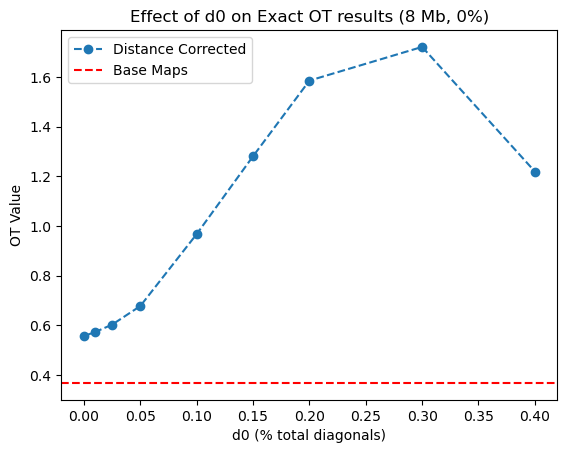

In [15]:
### Plotting d0 ###
d0_df.plot(x='d0 (% total diagonals)', y='ot_value', marker="o", linestyle="--", label="Distance Corrected")
plt.xlabel("d0 (% total diagonals)")
plt.ylabel("OT Value")
plt.axhline(base_ot, c="red", linestyle="--", label="Base Maps")
plt.legend()
plt.title(f"Effect of d0 on Exact OT results ({res} Mb, 0%)")

Text(0.5, 1.0, 'Effect of d1 on Exact OT results (8 Mb, 0%)')

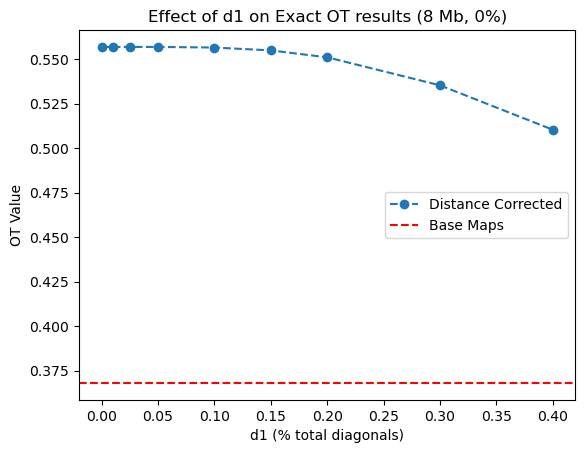

In [16]:
### Plotting d1 ###
d1_df.plot(x='d1 (% total diagonals)', y='ot_value', marker="o", linestyle="--", label="Distance Corrected")
plt.xlabel("d1 (% total diagonals)")
plt.ylabel("OT Value")
plt.axhline(base_ot, c="red", linestyle="--", label="Base Maps")
plt.legend()
plt.title(f"Effect of d1 on Exact OT results ({res} Mb, 0%)")